--- Step 1: Automatically Finding and Loading CSV File ---
✅ Found file: GlobalWeatherRepository.csv
Data Cleaning and Preprocessing Complete!

--- Step 2: Generating Visualizations ---


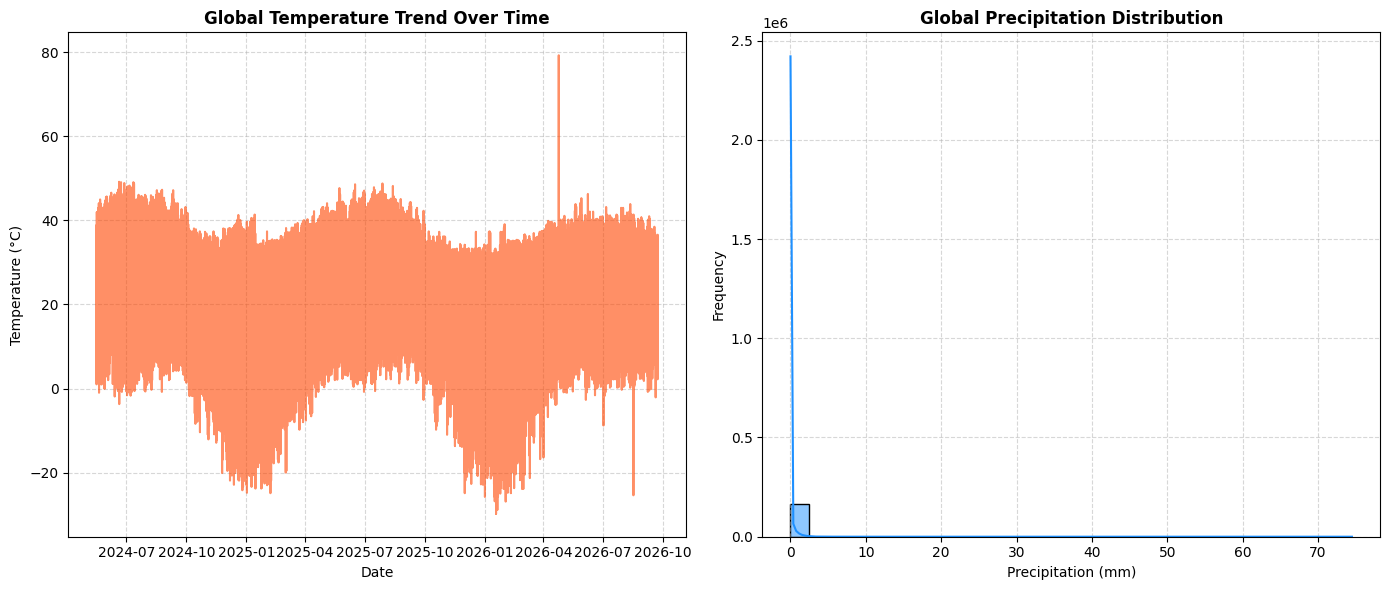


--- Step 3: Training Forecasting Model ---
Mean Squared Error (MSE): 84.9610
R-squared (R2) Score: 0.0135

--- Code Executed Successfully! ---


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("--- Step 1: Automatically Finding and Loading CSV File ---")

# Automatically detect any CSV file in the current folder
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
if not csv_files:
    print("❌ ERROR: CSV file not found! Please check the left panel.")
else:
    file_name = csv_files[0]
    print(f"✅ Found file: {file_name}")
    df = pd.read_csv(file_name)

    # Convert last_updated column to datetime format
    if 'last_updated' in df.columns:
        df['last_updated'] = pd.to_datetime(df['last_updated'])
    else:
        date_col = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()][0]
        df['last_updated'] = pd.to_datetime(df[date_col])
          # Handle missing values using column mean for numerical features
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

    # Fill categorical missing values with 'Unknown'
    cat_cols = df.select_dtypes(exclude=[np.number]).columns
    df[cat_cols] = df[cat_cols].fillna('Unknown')
    print("Data Cleaning and Preprocessing Complete!")
     # ---------------------------------------------------------------------
    # PART 2: EXPLORATORY DATA ANALYSIS & VISUALIZATION
    # ---------------------------------------------------------------------
    print("\n--- Step 2: Generating Visualizations ---")
    plt.figure(figsize=(14, 6))

    # Plot 1: Global Temperature Trend Over Time
    temp_col = [col for col in df.columns if 'temp' in col.lower() and 'c' in col.lower()][0]
    df_sorted = df.sort_values('last_updated')
    plt.subplot(1, 2, 1)
    plt.plot(df_sorted['last_updated'], df_sorted[temp_col], color='orangered', alpha=0.6)
    plt.title('Global Temperature Trend Over Time', fontsize=12, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Global Precipitation Distribution
    precip_col = [col for col in df.columns if 'precip' in col.lower() or 'rain' in col.lower()][0]
    plt.subplot(1, 2, 2)
    sns.histplot(df[precip_col], bins=30, kde=True, color='dodgerblue')
    plt.title('Global Precipitation Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Precipitation (mm)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('weather_trends_output.png')
    plt.show()
    # ---------------------------------------------------------------------
    # PART 3: MODEL BUILDING & TESTING (QA COMPLIANT)
    # ---------------------------------------------------------------------
    print("\n--- Step 3: Training Forecasting Model ---")
    # Convert date to numeric seconds for machine learning compatibility
    df['date_numeric'] = df['last_updated'].astype('int64') // 10**9
    X = df[['date_numeric']]
    y = df[temp_col]

    # Split data: 80% Training and 20% Testing for model quality validation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    # Predict values on test dataset
    y_pred = model.predict(X_test)

    # Calculate model verification and error metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"R-squared (R2) Score: {r2:.4f}")
    print("\n--- Code Executed Successfully! ---")